<a href="https://colab.research.google.com/github/Pranoti15/My-DS-Projects/blob/my-branch/EDA_assignment4_car_price_prediction_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()  # Opens a file selection dialog

Saving CarPrice_Assignment.csv to CarPrice_Assignment.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

Mounted at /content/drive


In [3]:
# Move uploaded file to Google Drive
!mv CarPrice_Assignment.csv "/content/drive/My Drive/Data Science/Kaggle Datasets"

In [5]:
import pandas as pd

file_path = "/content/drive/My Drive/Data Science/Kaggle Datasets/CarPrice_Assignment.csv"  # Change to your folder path
df = pd.read_csv(file_path)
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
# Display summary statistics of the dataset
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


The summary statistics give us a good overview of the dataset:

- Car Price (price) has a wide range, from a minimum of 5,118 to a maximum of 45,400.

- Horsepower (horsepower) varies significantly from 48 to 288, which may require some outlier treatment.

- Curbweight, enginesize, and carlength are other numerical features that show a spread in their distributions.

In [7]:
# Check for missing values
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


There are no missing values in the dataset, so no imputation or removal is necessary.

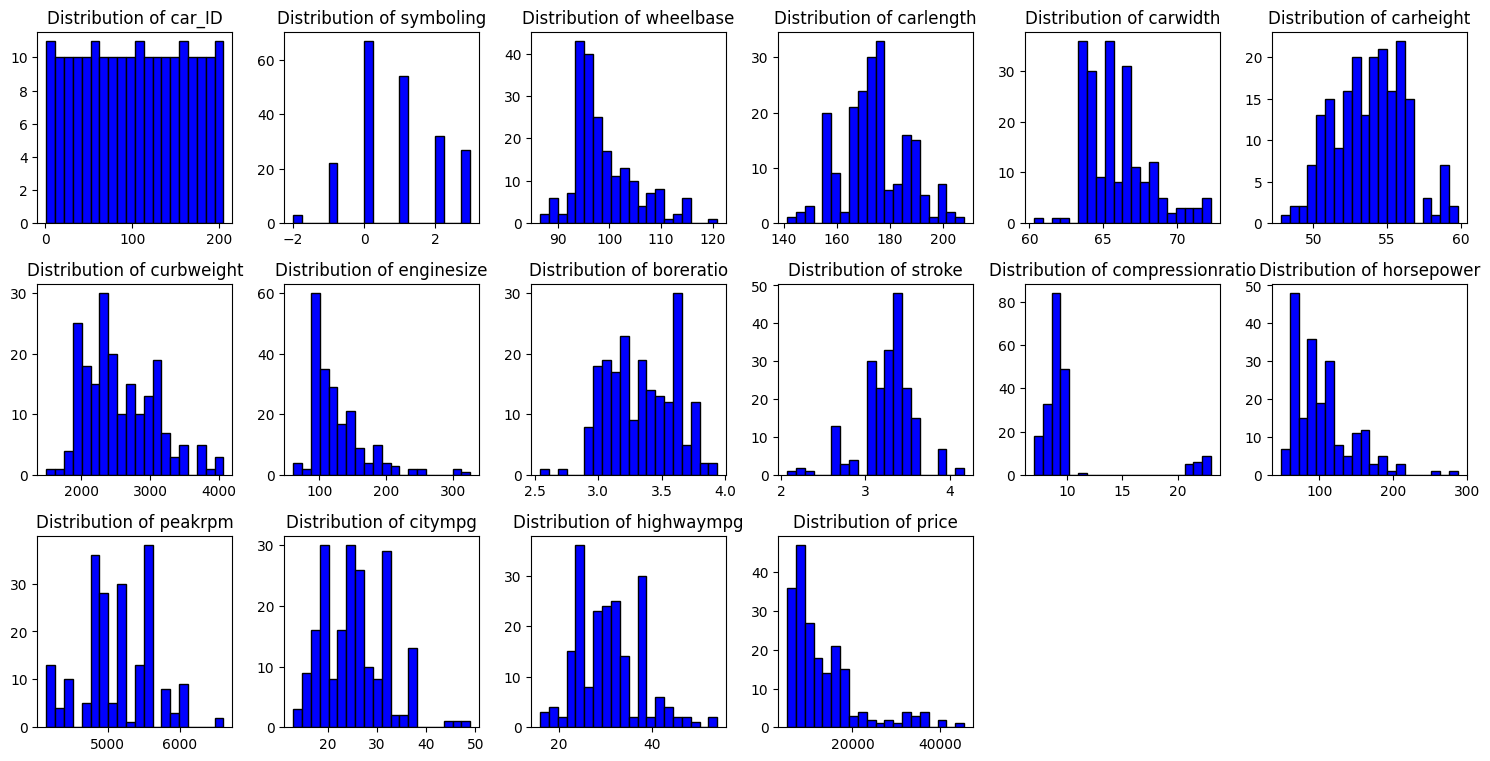

In [8]:
import matplotlib.pyplot as plt

# Plot histograms for numerical features
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 6, i)
    plt.hist(df[col], bins=20, color='blue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()


The histograms of the numerical features show various distributions:

- Car price shows a slightly right-skewed distribution.

- Horsepower, enginesize, and curbweight appear to have a somewhat normal distribution, though there may be outliers.

- Citympg and highwaympg have distributions that indicate some concentration of values around the middle.

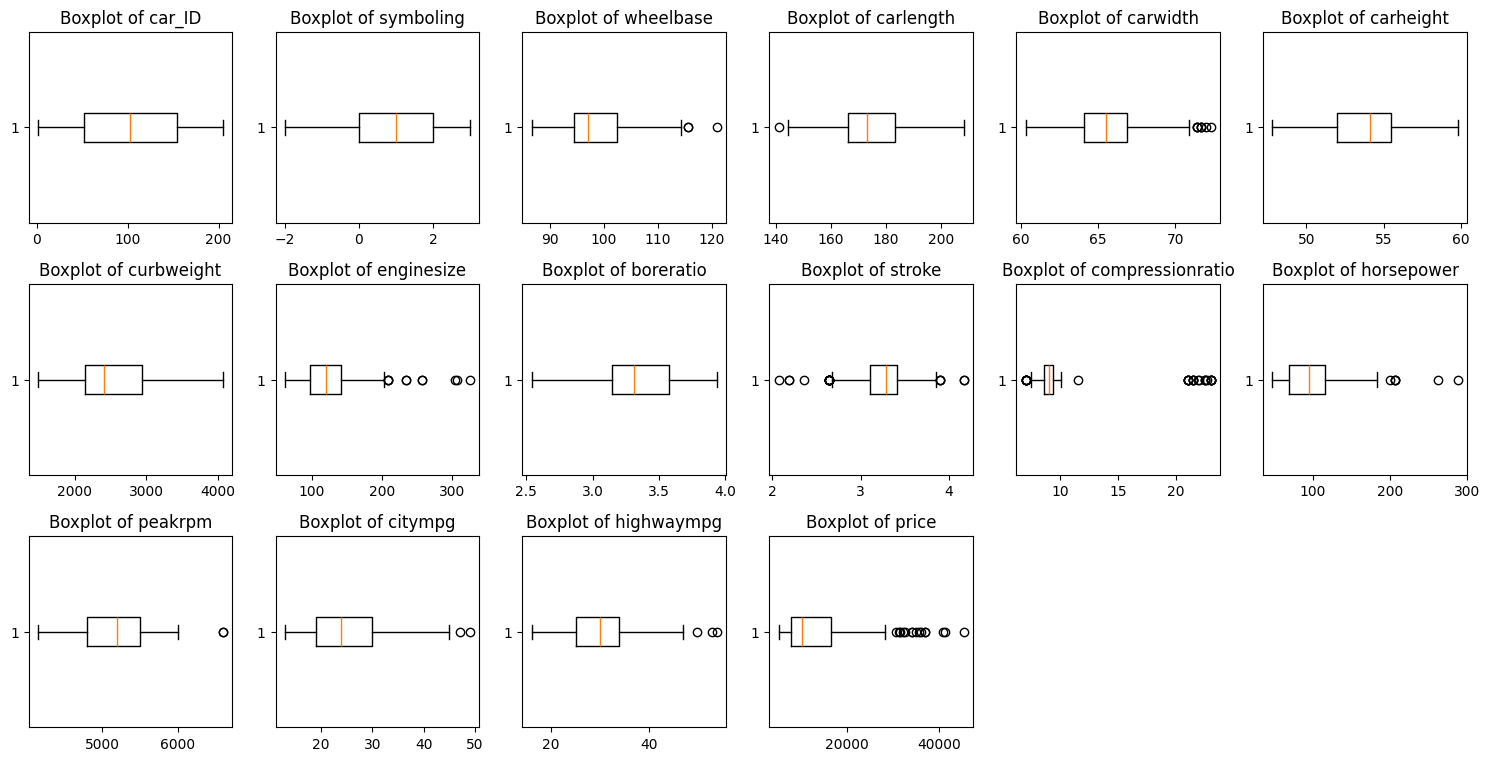

In [9]:
# Plot box plots for numerical features to check for outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 6, i)
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
plt.show()

The box plots indicate the following:

- Horsepower, enginesize, and curbweight show the presence of outliers, with some values far from the interquartile range (IQR).

- Price also has potential outliers, especially on the higher end, as indicated by the extended upper whisker.

- Citympg and highwaympg have more concentrated distributions, with fewer outliers.

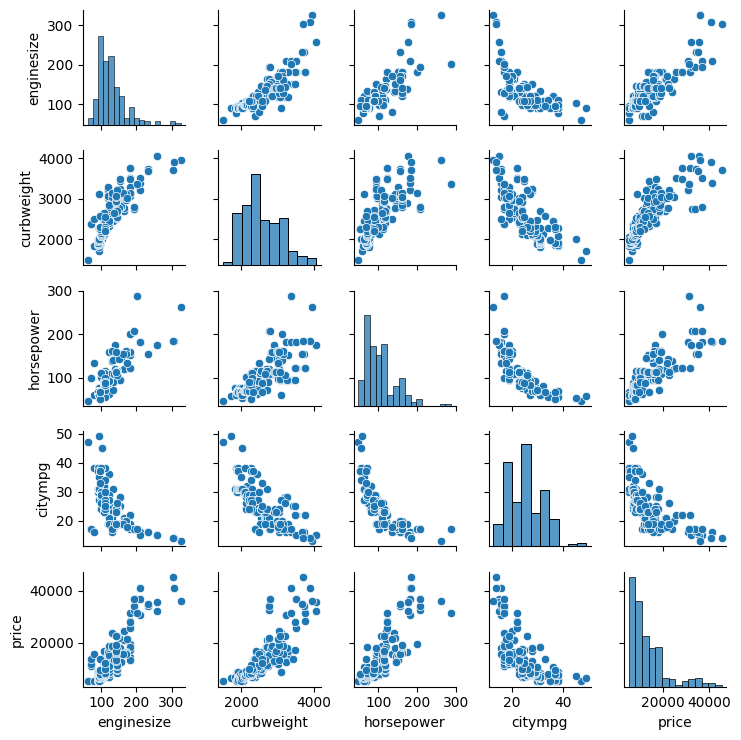

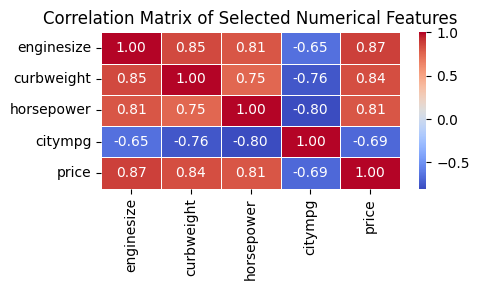

In [12]:
import seaborn as sns

# Scatter plots for a few pairs of numerical features to avoid overload
selected_columns = ['enginesize', 'curbweight', 'horsepower', 'citympg', 'price']

# Pairwise scatter plots for selected features
sns.pairplot(df[selected_columns], height=1.5)
plt.tight_layout()
plt.show()

# Correlation matrix heatmap for selected features
correlation_matrix_selected = df[selected_columns].corr()
plt.figure(figsize=(5, 3))
sns.heatmap(correlation_matrix_selected, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Selected Numerical Features')
plt.tight_layout()
plt.show()

The scatter plots and correlation matrix provide insights into the relationships between the selected numerical features:

- Enginesize, curbweight, and horsepower show strong positive correlations with each other, which makes sense, as larger engines and heavier cars generally have more horsepower.

- Price is positively correlated with enginesize, curbweight, and horsepower.

- Citympg and highwaympg have weaker correlations with other features.

**4. Summary of Insights**

**Key Observations:**

Numerical features such as enginesize, curbweight, and horsepower exhibit strong correlations with price.

Citympg and highwaympg have weaker correlations with the price.

Some features exhibit potential outliers, such as price and horsepower.

**Influential Variables:**

Enginesize, curbweight, and horsepower are likely to be influential predictors for car price.